In [6]:
import pandas as pd
import numpy as np
path = '../data/'
df = pd.read_csv(path + 'Telco-churn-preprocessed.csv')
df.head()

,customerID,tenure,MonthlyCharges,TotalCharges,Churn,num_internet_addons,num_streaming_services,total_services,has_premium_support,avg_monthly_charges,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,1,29.85,29.85,No,1,0,1,0,14.925000,...,False,False,False,False,False,False,True,False,True,False
1,5575-GNVDE,34,56.95,1889.50,No,2,0,3,0,53.985714,...,False,False,False,False,True,False,False,False,False,True
2,3668-QPYBK,2,53.85,108.15,Yes,2,0,3,0,36.050000,...,False,False,False,False,False,False,True,False,False,True
3,7795-CFOCW,45,42.30,1840.75,No,3,0,3,1,40.016304,...,False,False,False,False,True,False,False,False,False,False
4,9237-HQITU,2,70.70,151.65,Yes,0,0,1,0,50.550000,...,False,False,False,False,False,False,True,False,True,False


In [7]:
df.isnull().sum()

customerID                                0
tenure                                    0
MonthlyCharges                            0
TotalCharges                             11
Churn                                     0
num_internet_addons                       0
num_streaming_services                    0
total_services                            0
has_premium_support                       0
avg_monthly_charges                      11
clv_ratio                                11
is_early_tenure                           0
is_month_to_month                         0
contract_months                           0
has_paperless_billing                     0
has_automatic_payment                     0
uses_electronic_check                     0
gender_Male                               0
SeniorCitizen_1                           0
Partner_Yes                               0
Dependents_Yes                            0
PhoneService_Yes                          0
MultipleLines_No phone service  

In [8]:
df.fillna(0, inplace = True)

,customerID,tenure,MonthlyCharges,TotalCharges,Churn,num_internet_addons,num_streaming_services,total_services,has_premium_support,avg_monthly_charges,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,1,29.85,29.85,No,1,0,1,0,14.925000,...,False,False,False,False,False,False,True,False,True,False
1,5575-GNVDE,34,56.95,1889.50,No,2,0,3,0,53.985714,...,False,False,False,False,True,False,False,False,False,True
2,3668-QPYBK,2,53.85,108.15,Yes,2,0,3,0,36.050000,...,False,False,False,False,False,False,True,False,False,True
3,7795-CFOCW,45,42.30,1840.75,No,3,0,3,1,40.016304,...,False,False,False,False,True,False,False,False,False,False
4,9237-HQITU,2,70.70,151.65,Yes,0,0,1,0,50.550000,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,24,84.80,1990.50,No,3,2,6,1,79.620000,...,False,True,False,True,True,False,True,False,False,True
7039,2234-XADUH,72,103.20,7362.90,No,2,2,5,0,100.861644,...,False,True,False,True,True,False,True,True,False,False
7040,4801-JZAZL,11,29.60,346.45,No,1,0,1,0,28.870833,...,False,False,False,False,False,False,True,False,True,False
7041,8361-LTMKD,4,74.40,306.60,Yes,0,0,1,0,61.320000,...,False,False,False,False,False,False,True,False,False,True


In [9]:
from sklearn.model_selection import train_test_split
from optuna import create_study
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

scaler = StandardScaler()

X = df.drop(columns=['Churn', 'customerID'])
y = df['Churn'].map({'No': 0, 'Yes': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# def objective(trial):

#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 500, 2000, step=100),
#         'max_depth': trial.suggest_int('max_depth', 4, 15),
#         'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
#         'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 7),
#         'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
#     }

#     model = Pipeline([
#         ('scaler', StandardScaler()),
#         ('rf', RandomForestClassifier(
#             **params
#         ))
#     ])

#     model.fit(X_train, y_train)

#     return model.score(X_test, y_test)

# study = create_study(direction='maximize')

# study.optimize(objective, n_trials=50, show_progress_bar=True)


Accuracy:
0.8069552874378992

ROC AUC:
0.8442868583533545

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



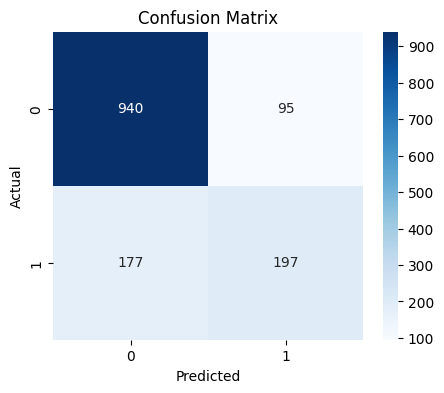

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
best_params = {'n_estimators': 500, 'max_depth': 9, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'log2'}
rf_model = RandomForestClassifier(
    **best_params,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))
print("\nROC AUC:")
print(roc_auc_score(y_test, y_prob))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


Top 10 Important Features:
                        Feature  Importance
8                     clv_ratio    0.102492
0                        tenure    0.090706
10            is_month_to_month    0.088558
11              contract_months    0.080019
1                MonthlyCharges    0.069244
2                  TotalCharges    0.065248
22  InternetService_Fiber optic    0.058201
7           avg_monthly_charges    0.057983
9               is_early_tenure    0.034287
14        uses_electronic_check    0.033569


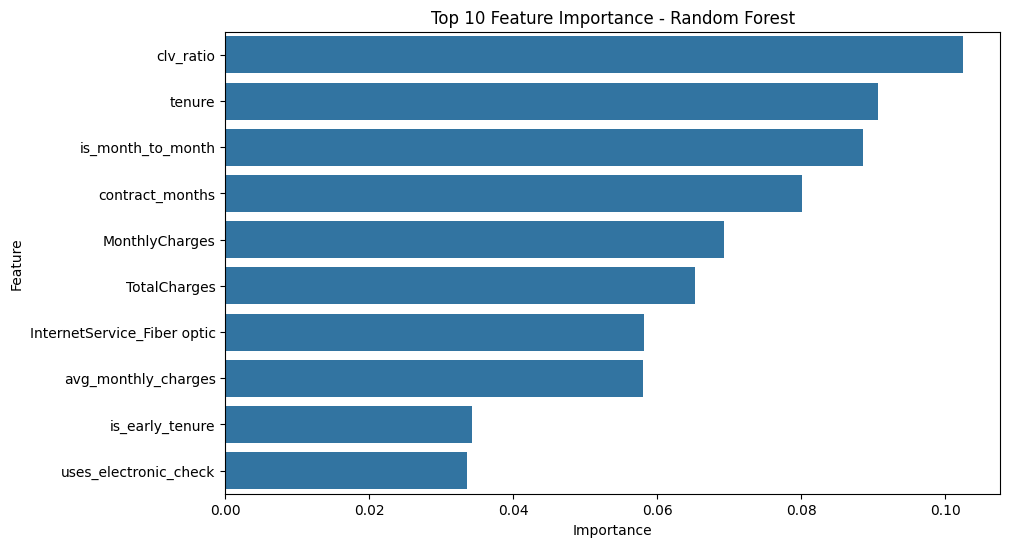

In [11]:
# Feature Importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop 10 Important Features:")
print(importance_df.head(10))
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance_df.head(10),
    x='Importance',
    y='Feature'
)
plt.title("Top 10 Feature Importance - Random Forest")
plt.show()

In [16]:
y_predicted = rf_model.predict(X_test)
predicted_churn = pd.Series(y_predicted, index=X_test.index).map({0: 'No', 1: 'Yes'})
data_with_predicted_labels = X_test.copy()
data_with_predicted_labels['Predicted_Churn'] = predicted_churn

In [17]:
data_with_predicted_labels.to_csv('../data/test_data_with_predictions.csv', index=False)

In [18]:
data_with_predicted_labels.isnull().sum()

tenure                                   0
MonthlyCharges                           0
TotalCharges                             0
num_internet_addons                      0
num_streaming_services                   0
total_services                           0
has_premium_support                      0
avg_monthly_charges                      0
clv_ratio                                0
is_early_tenure                          0
is_month_to_month                        0
contract_months                          0
has_paperless_billing                    0
has_automatic_payment                    0
uses_electronic_check                    0
gender_Male                              0
SeniorCitizen_1                          0
Partner_Yes                              0
Dependents_Yes                           0
PhoneService_Yes                         0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetSer